In [1]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans

In [2]:
# path to the songs folder
song_folder = "./Songs"

song_files = os.listdir(song_folder)
file_ext = ['.mp3', '.wav', '.aiff']
song_files = [file for file in song_files if any(file.endswith(ext) for ext in file_ext)]

features = []

In [3]:
for song_file in song_files:
    if song_file.endswith(".mp3") or song_file.endswith(".wav") or song_file.endswith(".aiff"):
        song_path = os.path.join(song_folder, song_file)
        y, sr = librosa.load(song_path)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        spectral_flatness = np.mean(librosa.feature.spectral_flatness(y=y))
        rms = np.mean(librosa.feature.rms(y=y))
        features.append([tempo, spectral_flatness, rms])

features = np.array(features)

In [4]:
min_max_scaler = sklearn.preprocessing.MinMaxScaler(feature_range=(0, 1))
features_scaled = min_max_scaler.fit_transform(features)
print(features_scaled.shape)
print(features_scaled.min(axis=0))
print(features_scaled.max(axis=0))

(10, 3)
[0. 0. 0.]
[1. 1. 1.]


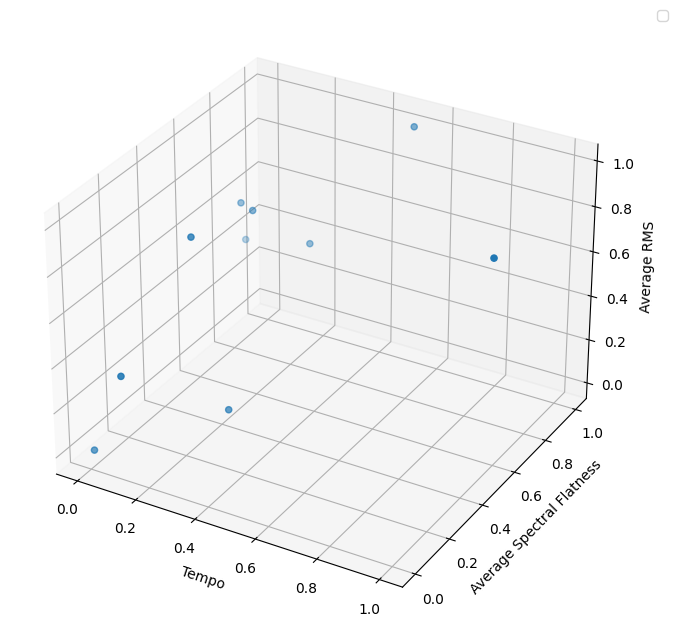

In [5]:
# make a 3D scatter plot of the songs with tempo on the X axis, average RMS on the Y axis,
# and average spectral flatness on the Z axis
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(features_scaled[:, 0], features_scaled[:, 1], features_scaled[:, 2])
ax.set_xlabel('Tempo')
ax.set_ylabel('Average Spectral Flatness')
ax.set_zlabel('Average RMS')
ax.legend(*ax.get_legend_handles_labels(), bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

plt.show()

In [6]:
import warnings
warnings.filterwarnings("ignore")
# use k-means to sort the songs into two groups
kmeans = KMeans(n_clusters=3, random_state=0).fit(features_scaled)
labels = kmeans.labels_

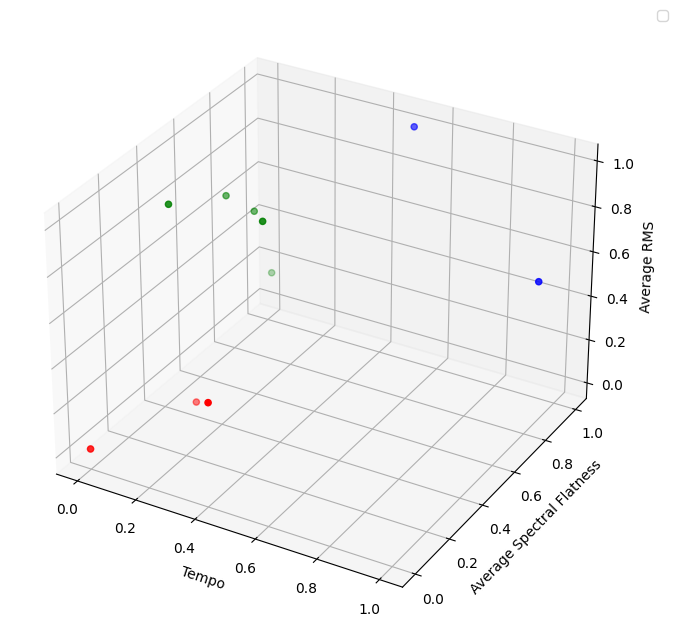

In [7]:
# Plot the songs in a 3D scatter plot with colors indicating which kmeans group the song belongs to
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['r' if label == 0 else 'b' if label == 1 else 'g' for label in labels]

ax.scatter(features_scaled[:, 0], features_scaled[:, 2], features_scaled[:, 1], c=colors)

ax.set_xlabel('Tempo')
ax.set_ylabel('Average Spectral Flatness')
ax.set_zlabel('Average RMS')
ax.legend(*ax.get_legend_handles_labels(), bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

plt.show()

In [8]:
# Print the contents of the clusters
for i in range(3):
    print(f'Cluster {i+1}:')
    print(np.array(song_files)[labels == i])

Cluster 1:
['So Far Away.aiff' "It's Too Late.aiff" "You've Got A Friend.aiff"]
Cluster 2:
['Little Town Flirt.aiff' 'Baby I Love You.aiff']
Cluster 3:
['Just Because.aiff' 'Rules.aiff' 'The Thrill Is Gone.aiff'
 'Good Love.aiff' 'Runaway.aiff']
